Libraries Imported!

Dataset Loaded!
Shape: (150, 5)
   sepal_length  sepal_width  petal_length  petal_width      species
0           5.1          3.5           1.4          0.2  Iris-setosa
1           4.9          3.0           1.4          0.2  Iris-setosa
2           4.7          3.2           1.3          0.2  Iris-setosa
3           4.6          3.1           1.5          0.2  Iris-setosa
4           5.0          3.6           1.4          0.2  Iris-setosa

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
None

Missing Values:
sepal_length    0
sepal_width     0
pet

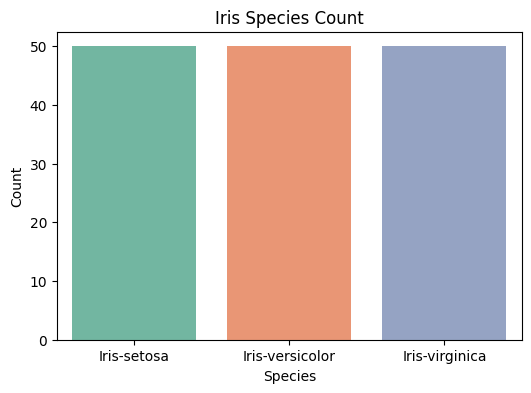

<Figure size 800x600 with 0 Axes>

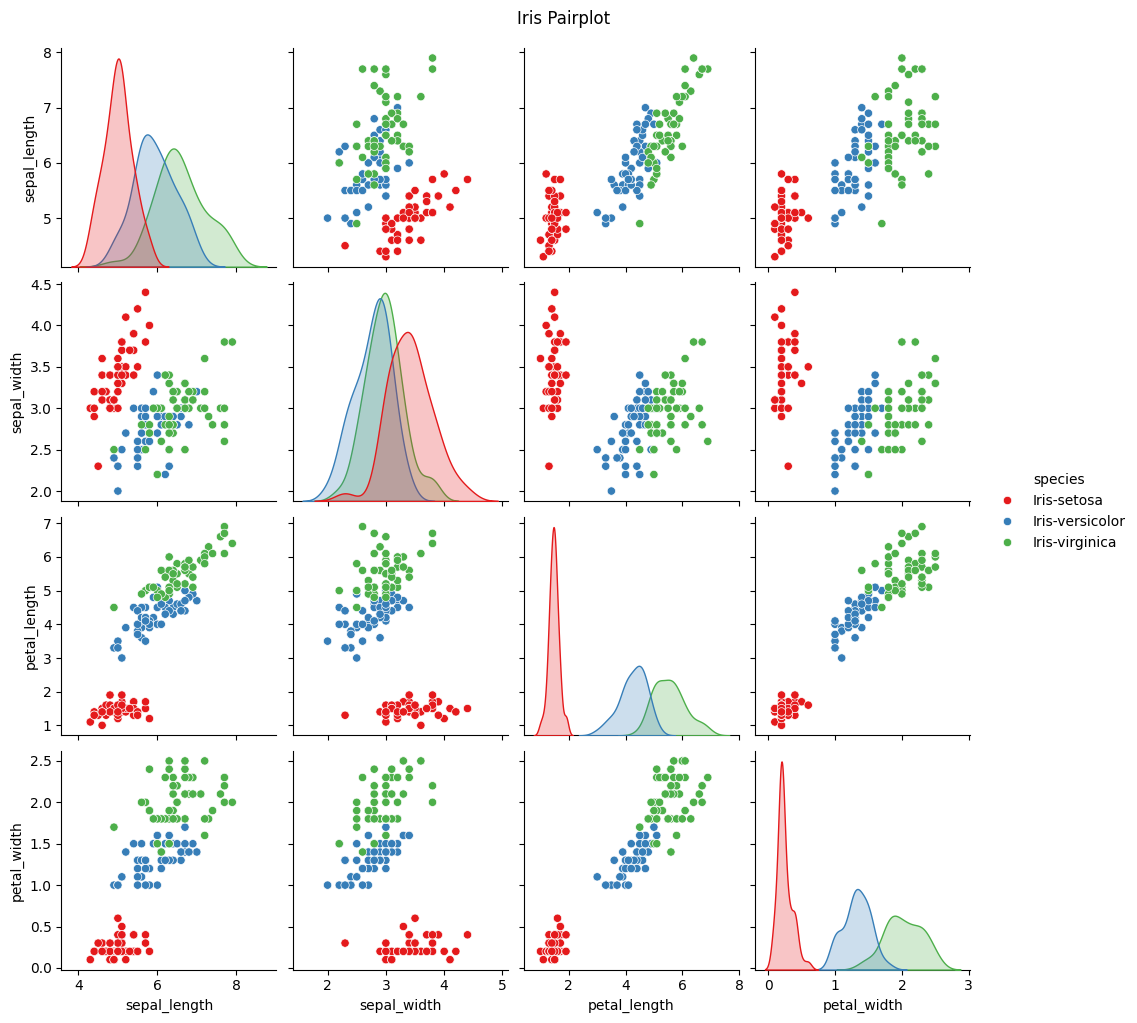

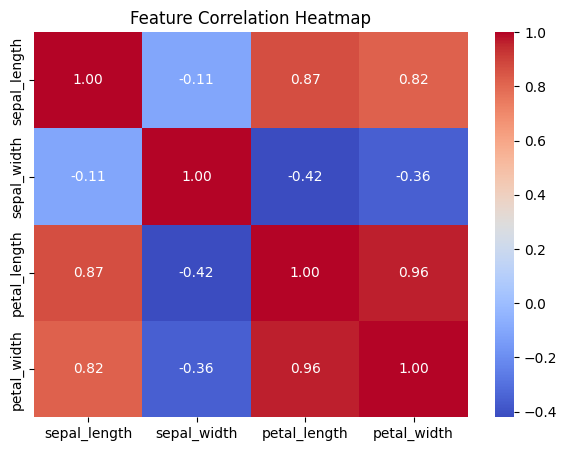

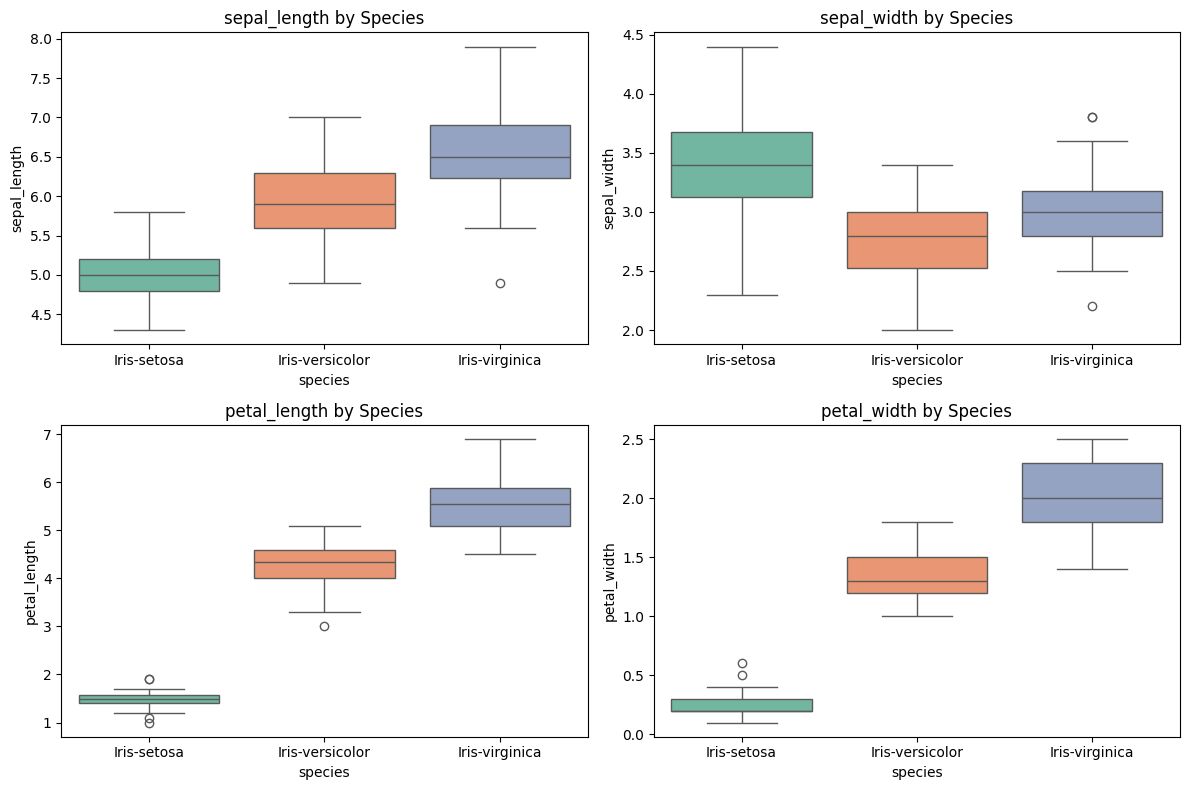

EDA Complete!

Preprocessing Done!
   sepal_length  sepal_width  petal_length  petal_width  species
0           5.1          3.5           1.4          0.2        0
1           4.9          3.0           1.4          0.2        0
2           4.7          3.2           1.3          0.2        0
3           4.6          3.1           1.5          0.2        0
4           5.0          3.6           1.4          0.2        0

Data Split Done!
Training samples: 120
Testing samples: 30

Model Trained!

Model Accuracy: 100.00%

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



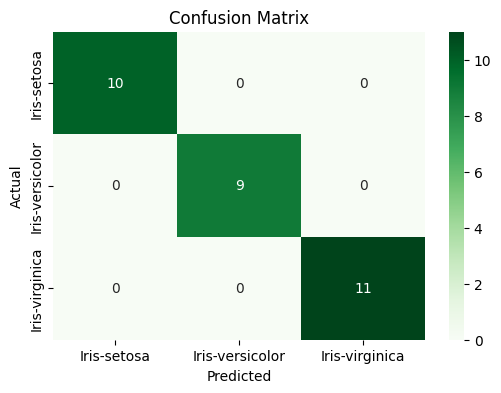

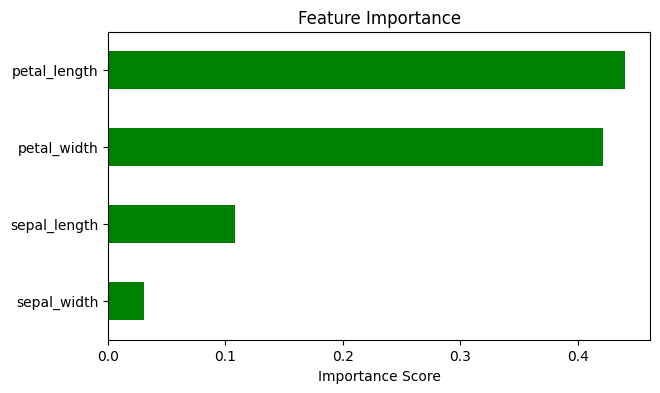


Task 3 - Iris Flower Classification COMPLETE!


In [2]:
# Task 3 - Iris Flower Classification
# CodSoft Data Science Internship

# ============================================================
# STEP 1: Import Libraries
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

print("Libraries Imported!")

# ============================================================
# STEP 2: Load Dataset
# ============================================================
df = pd.read_csv('IRIS.csv')
print("\nDataset Loaded!")
print(f"Shape: {df.shape}")
print(df.head())

# ============================================================
# STEP 3: Exploratory Data Analysis
# ============================================================
print("\nDataset Info:")
print(df.info())
print("\nMissing Values:")
print(df.isnull().sum())
print("\nBasic Statistics:")
print(df.describe())
print("\nSpecies Count:")
print(df['species'].value_counts())

# Species Count Plot
plt.figure(figsize=(6,4))
sns.countplot(x='species', data=df, palette='Set2')
plt.title('Iris Species Count')
plt.xlabel('Species')
plt.ylabel('Count')
plt.show()

# Pairplot
plt.figure(figsize=(8,6))
sns.pairplot(df, hue='species', palette='Set1')
plt.suptitle('Iris Pairplot', y=1.02)
plt.show()

# Correlation Heatmap
plt.figure(figsize=(7,5))
sns.heatmap(df.drop('species', axis=1).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

# Boxplots
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
for i, feature in enumerate(features):
    sns.boxplot(x='species', y=feature, data=df, palette='Set2', ax=axes[i//2][i%2])
    axes[i//2][i%2].set_title(f'{feature} by Species')
plt.tight_layout()
plt.show()

print("EDA Complete!")

# ============================================================
# STEP 4: Data Preprocessing
# ============================================================
le = LabelEncoder()
df['species'] = le.fit_transform(df['species'])
# setosa=0, versicolor=1, virginica=2

print("\nPreprocessing Done!")
print(df.head())

# ============================================================
# STEP 5: Train/Test Split
# ============================================================
X = df.drop('species', axis=1)
y = df['species']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nData Split Done!")
print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

# ============================================================
# STEP 6: Train Model
# ============================================================
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
print("\nModel Trained!")

# ============================================================
# STEP 7: Evaluate Model
# ============================================================
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"\nModel Accuracy: {accuracy * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Confusion Matrix
plt.figure(figsize=(6,4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Feature Importance
plt.figure(figsize=(7,4))
feat_importance = pd.Series(model.feature_importances_, index=X.columns)
feat_importance.sort_values().plot(kind='barh', color='green')
plt.title('Feature Importance')
plt.xlabel('Importance Score')
plt.show()

print("\nTask 3 - Iris Flower Classification COMPLETE!")